In [1]:
# Initialisation 

## vérifier à la fin si on utilise bien tout ces import ##

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns

df = pd.read_csv("../output/df_modele_musees.csv")

## Statistiques descriptives

In [3]:
#Aperçu du dataframe : une ligne = un musée pour une année
#df.info()

#Stat desc sur le total de fréquentation
df["total"].describe()

count    1.124800e+04
mean     5.018695e+04
std      3.477633e+05
min      0.000000e+00
25%      2.029500e+03
50%      8.481000e+03
75%      2.650125e+04
max      1.010596e+07
Name: total, dtype: float64

Ce résumé nous donne une première idée des caractéristiques de notre dataset, afin de faire des graphiques plus pertinents par la suite. Par exemple, le fait que l'écart-type soit très grand signifie qu'il y a une forte hétérogénéité entre les musées. Cela se voit de plus car la médiane est de 8 481 visiteurs et la moyenne de 50 186 visiteurs : quelques musées connus concentrent la majorité des visites.

## Représentation géographique

In [4]:
#DF GEO 
# On enlève les lignes sans coordonnées
df_geo = df.dropna(subset=["latitude", "longitude"]).copy()

# Création de la colonne geometry à partir de lon/lat
gdf_points = gpd.GeoDataFrame(
    df_geo,
    geometry=gpd.points_from_xy(df_geo["longitude"], df_geo["latitude"]),
    crs="EPSG:4326"  # WGS84, le classique lat/lon
)

gdf_points.head()


,id_patrimostat,id_museofile,dateappellation,ferme,anneefermeture,ville,codeInseeCommune,annee,payant,gratuit,...,latitude,longitude,total_frequentation,age_musee,age_musee_missing,total_t_1,croissance_total,has_excel,est_idf,geometry
0,6702101,M0001,01/02/2003,NON,NaN,BARR,67021,2014,1865.0,2685.0,...,48.410166,7.451102,4550.0,54.0,0,NaN,NaN,1,0,POINT (7.4511 48.41017)
1,6702101,M0001,01/02/2003,NON,NaN,BARR,67021,2015,1874.0,1934.0,...,48.410166,7.451102,3808.0,55.0,0,4550.0,-0.163077,1,0,POINT (7.4511 48.41017)
2,6702101,M0001,01/02/2003,NON,NaN,BARR,67021,2016,1705.0,1409.0,...,48.410166,7.451102,3114.0,56.0,0,3808.0,-0.182248,1,0,POINT (7.4511 48.41017)
3,6702101,M0001,01/02/2003,NON,NaN,BARR,67021,2017,1163.0,1281.0,...,48.410166,7.451102,2444.0,57.0,0,3114.0,-0.215157,1,0,POINT (7.4511 48.41017)
4,6702101,M0001,01/02/2003,NON,NaN,BARR,67021,2018,1249.0,2341.0,...,48.410166,7.451102,3590.0,58.0,0,2444.0,0.468903,1,0,POINT (7.4511 48.41017)


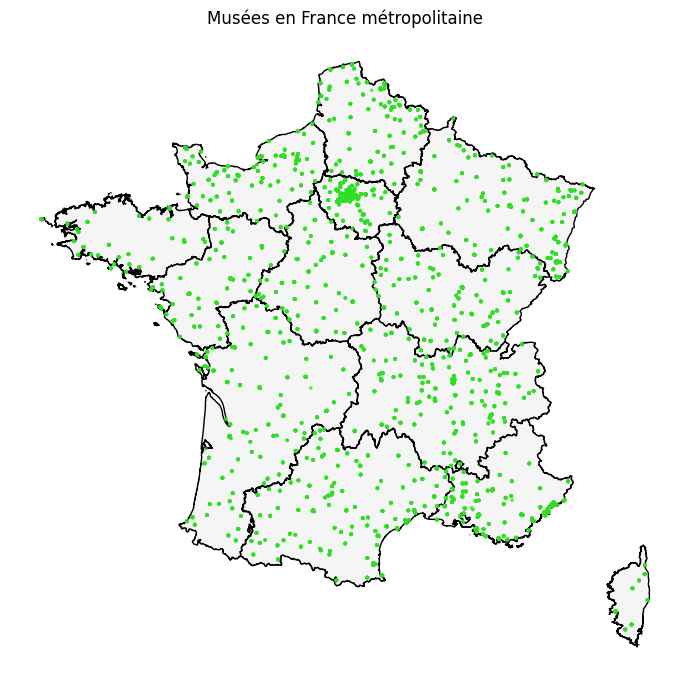

In [5]:
from cartiflette import carti_download
#carte des musées en FR métro
#Filtre France métropolitaine sur les points
mask_metropole = (
    gdf_points.geometry.y.between(41, 52) &   # latitude
    gdf_points.geometry.x.between(-6, 10)     # longitude
)
gdf_points_metropole = gdf_points[mask_metropole].copy()

#Télécharger la carte des régions
france = carti_download(
    values=["France"],
    crs=4326,
    borders="REGION",
    vectorfile_format="geojson",
    simplification=50,
    filter_by="FRANCE_ENTIERE",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022
)

# garder seulement la métropole
france = france.loc[france["INSEE_REG"] > 10]

#Tracer
fig, ax = plt.subplots(figsize=(7, 9))

# fond de carte
france.plot(ax=ax, color="whitesmoke", edgecolor="black")

# taille des points bornée (évite la grosse tache)
ms = np.clip(gdf_points_metropole["total"] / 100000, 3, 20)

gdf_points_metropole.plot(
    ax=ax,
    markersize=ms,
    color="#2ee021",
    alpha=0.6
)

ax.set_title("Musées en France métropolitaine")
ax.set_axis_off()
plt.tight_layout()
plt.show()

#voir ce qu'on peut faire avec données insee (touristes, densité)

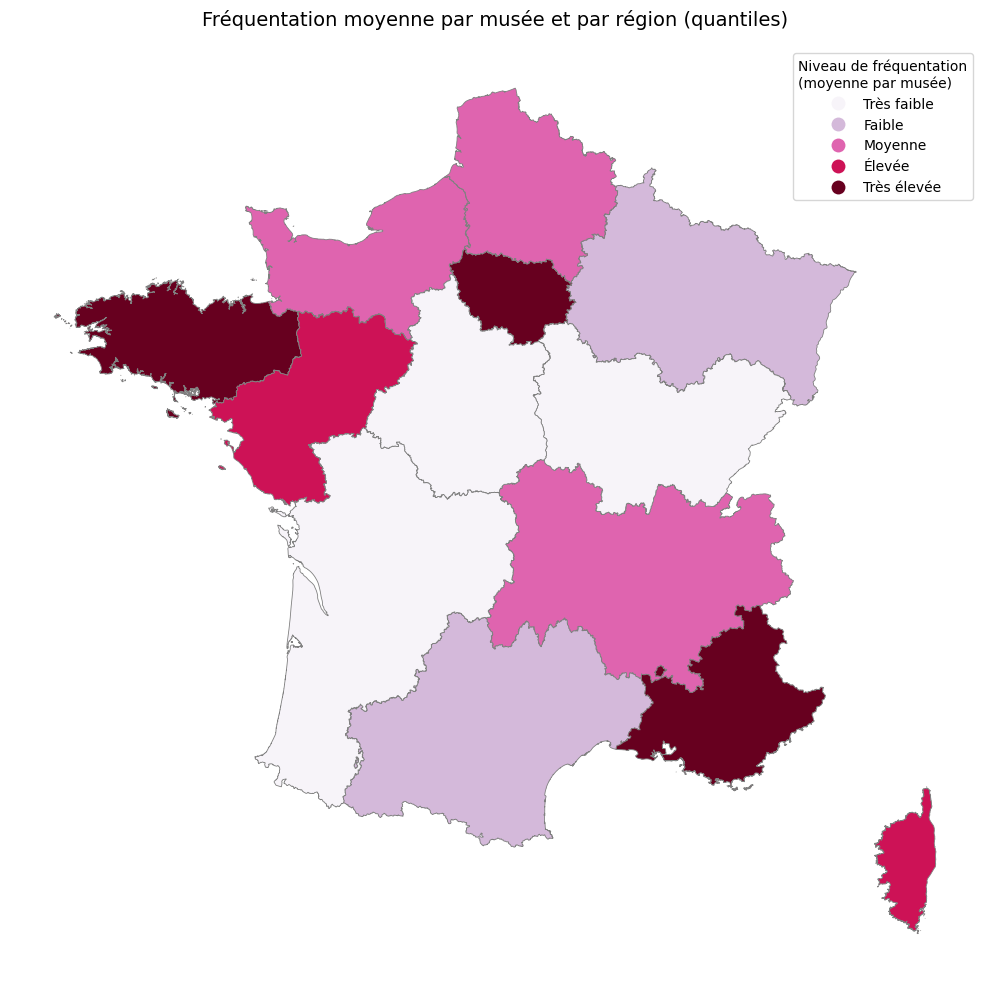

In [6]:
#CARTE FREQ MOY
import mapclassify


#Fréquentation moyenne par musée dans chaque région
df_region = (
    df.groupby("region")
      .agg(
          visites_totales=("total", "sum"),
          nb_musees=("id_museofile", "nunique")
      )
)

df_region["freq_par_musee"] = df_region["visites_totales"] / df_region["nb_musees"]
df_region = df_region.reset_index()

#Fonction de normalisation des noms de régions
def normalize_name(s):
    """Met les noms de région en minuscule, enlève les espaces et harmonise les tirets."""
    if pd.isna(s):
        return np.nan
    s = str(s).lower()
    s = s.replace("–", "-").replace("—", "-")  # différents tirets → '-'
    s = s.replace("  ", " ")
    return s.strip()

#réer region_clean côté données et côté carte
df_region["region_clean"] = df_region["region"].apply(normalize_name)
france["region_clean"] = france["LIBELLE_REGION"].apply(normalize_name)

#Corrections manuelles sur quelques régions
mapping = {
    "pays-de-la-loire": "pays de la loire",
    "provence-alpes-côte-d'azur": "provence-alpes-côte d'azur",
    "territoires et départements d'outre-mer": np.nan,  # on ignore, pas dans la carte
}

df_region["region_clean"] = df_region["region_clean"].replace(mapping)

#On enlève les lignes sans région métropolitaine
df_region = df_region.dropna(subset=["region_clean"])

#Jointure
france_reg = france.merge(
    df_region[["region_clean", "freq_par_musee"]],
    on="region_clean",
    how="left"
)

#On garde uniquement les régions avec données (métropole)
france_reg_clean = france_reg[france_reg["freq_par_musee"].notna()].copy()

#Classification en quantiles
scheme = mapclassify.Quantiles(france_reg_clean["freq_par_musee"], k=5)

#Tracé de la choroplèthe
fig, ax = plt.subplots(figsize=(10, 10))

france_reg_clean.plot(
    column="freq_par_musee",
    cmap="PuRd",
    legend=True,
    edgecolor="grey",
    linewidth=0.6,
    scheme="Quantiles",   
    k=5,                  
    ax=ax
)

#Légende qualitative
labels = ["Très faible", "Faible", "Moyenne", "Élevée", "Très élevée"]

leg = ax.get_legend()
leg.set_title("Niveau de fréquentation\n(moyenne par musée)")

for lbl, txt in zip(labels, leg.texts):
    txt.set_text(lbl)

ax.set_title("Fréquentation moyenne par musée et par région (quantiles)", 
             fontsize=14, pad=15)
ax.set_axis_off()

plt.tight_layout()
plt.show()


Les régions avec la plus grande fréquentation moyenne sont l'Île-de-France, la Bretagne et la Provence-Alpes-Côte-d'Azur, ce qui s'explique à la fois par la concentration de musées majeurs et l'attrait touristique de ces territoires. À l'inverse, l'apparition de la diagonale du vide, qui n'était pas marquée dans la carte précédente, illustre la disparité géographique dans l'accès à la culture en France.

### Scatter régional

In [7]:
# Agrégation régionale
df_region_scatter = (
    df.groupby("region")
      .agg(
          nb_musees=("id_museofile", "nunique"),
          freq_moyenne=("total", "mean")
      )
      .reset_index()
)

df_region_scatter["idf"] = (
    df_region_scatter["region"] == "Île-de-France"
)

df_region_scatter

,region,nb_musees,freq_moyenne,idf
0,Auvergne-Rhône-Alpes,134,26258.900715,False
1,Bourgogne-Franche-Comté,101,17650.010582,False
2,Bretagne,34,31615.033742,False
3,Centre-Val de Loire,64,16815.728242,False
4,Corse,10,27251.621053,False
5,Grand Est,120,22126.503534,False
6,Hauts-de-France,87,27613.285714,False
7,Normandie,90,22767.822115,False
8,Nouvelle-Aquitaine,112,17917.835378,False
9,Occitanie,131,22952.424448,False


## Analyse globale de la fréquentation

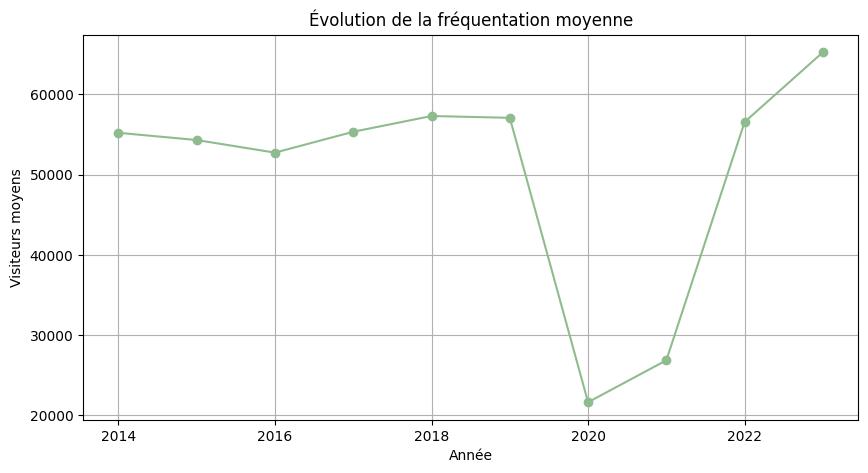

In [8]:
# ÉVOLUTION DE LA FRÉQUENTATION MOYENNE
df_year = df.groupby("annee")["total"].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(df_year["annee"], df_year["total"], marker="o", color ="darkseagreen")
plt.title("Évolution de la fréquentation moyenne")
plt.xlabel("Année")
plt.ylabel("Visiteurs moyens")
plt.grid(True)
plt.show()

Alors que la fréquentation moyenne pré-COVID stagnait autour de 55 000 de visiteurs par an, la chute due au COVID semble avoir lancé une nouvelle dynamique. On observe d'abord un retour à la normale en 2022, puis une hausse de la fréquentation moyenne en 2023. *Dans notre modélisation, nous tenterons donc de comprendre si cette hausse est exceptionnelle ou s'apparente à une nouvelle tendance de long-terme.*

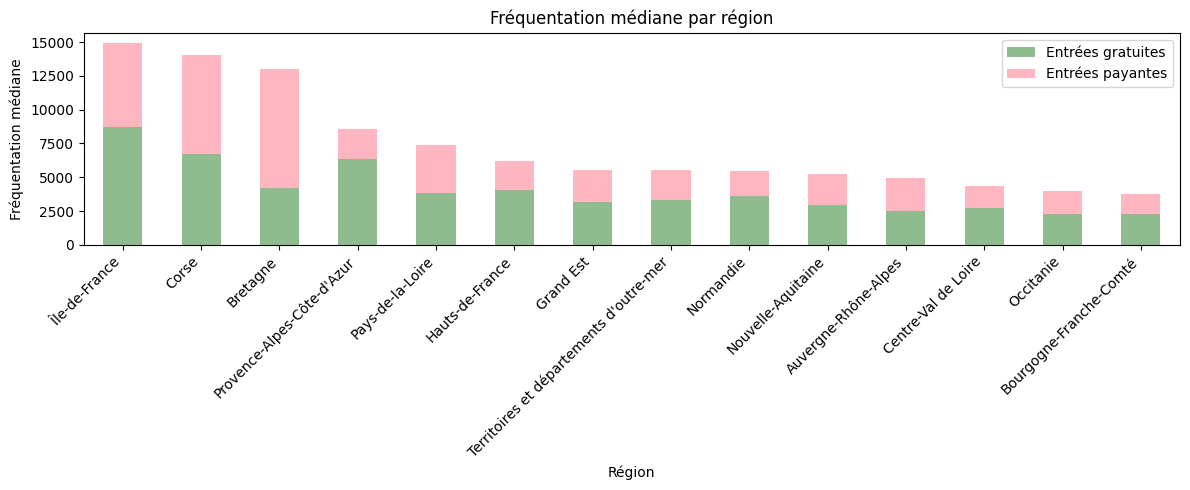

In [9]:
# FRÉQUENTATION MÉDIANE PAR RÉGION : ENTRÉES PAYANTES ET GRATUITES

df_med_sep = (
    df.groupby("region")[["gratuit", "payant"]]
      .median()
      .assign(total_med=lambda x: x["gratuit"] + x["payant"])   # création d'une colonne total pour le tri
      .sort_values("total_med", ascending=False)
)

df_med_sep[["gratuit", "payant"]].plot(  # affichage des colonnes gratuit et médian (pas total)
    kind="bar",
    stacked=True,   # barres empilées
    figsize=(12,5),
    color=["darkseagreen", "lightpink"]
)

plt.title("Fréquentation médiane par région")
plt.ylabel("Fréquentation médiane")
plt.xlabel("Région")
plt.xticks(rotation=45, ha="right")
plt.legend(["Entrées gratuites", "Entrées payantes"])
plt.tight_layout()
plt.show()

Dans un premier temps, nous avons tenté de regarder la fréquentation moyenne par région. Or, les valeurs atteintes par les musées d'Île-de-France n'étaient pas propices à la comparaison régionale. Nous nous sommes donc intéressées à la médiane qui permet une meilleure interprétation des tendances en limitant l'importance des valeurs aberrantes.

On observe que l'Île-de-France, la Corse et la Bretagne possèdent une fréquentation médiane similaire. Néanmoins, la structure de cette fréquentation diffère : les entrées gratuites représentent 57.9% des entrées totales en Île-de-France, alors que la Bretagne est l'une des régions avec la plus faible proportion d'entrées gratuites avec seulement 39.8%. Dans la majorité des régions, il apparaît que les entrées gratuites représentent plus de la moitié de la fréquentation médiane des musées.

In [8]:
# TOP 10 DES MUSÉES LES PLUS VISITÉS HORS IDF

df_sans_idf = df[df["region"] != "Île-de-France"]

top_musees_fr = (
    df_sans_idf.groupby("nom_officiel")
      .agg(                                       # sélectionner plusieurs colonnes pour le tableau
          total_visites=("total", "sum"),
          region=("region", "first"),                           
          domaine=("domaine_list", "first")
      )
      .sort_values("total_visites", ascending=False)
      .head(10)
      .reset_index()
)

top_musees_fr.columns = [
    "Nom du musée",
    "Total des visites",
    "Région",
    "Domaine thématique"
]

top_musees_fr

,Nom du musée,Total des visites,Région,Domaine thématique
0,musée des beaux-arts,22617440.0,Provence-Alpes-Côte-d'Azur,"['art moderne et contemporain', 'beaux-arts']"
1,muséum d'histoire naturelle,11473692.0,Provence-Alpes-Côte-d'Azur,['sciences de la nature']
2,musée des Confluences,11406554.0,Auvergne-Rhône-Alpes,"['art moderne et contemporain', 'beaux-arts', ..."
3,musée des civilisations de l'Europe et de la M...,4675648.0,Provence-Alpes-Côte-d'Azur,"['ethnologie', 'histoire']"
4,château musées,2741113.0,Centre-Val de Loire,"['archéologie', 'arts décoratifs', 'beaux-arts..."
5,musée archéologique,2582738.0,Auvergne-Rhône-Alpes,['archéologie']
6,musée du Débarquement,2541811.0,Normandie,['histoire']
7,musée du château des ducs de Bretagne,2531139.0,Pays-de-la-Loire,"['archéologie', 'arts décoratifs', 'art modern..."
8,Palais-musée des Archevêques de Narbonne,2417238.0,Occitanie,"['archéologie', 'arts décoratifs', 'art modern..."
9,musée municipal,2369975.0,Hauts-de-France,"['archéologie', 'beaux-arts', 'histoire']"


Dans un premier temps, il est important de souligner que seuls les deux premiers musées de ce classement arrivent à concurrencer les musées d'Île-de-France pour se classer dans le top 10 des musées français. On remarque de plus une différence sur les domaines thématiques qui attirent les visiteurs entre l'Île-de-France et le reste des régions. En effet, l'archéologie ne ressort pas beaucoup en Île-de-France, plutôt axée sur l'art, alors qu'elle est prépondérante en région.

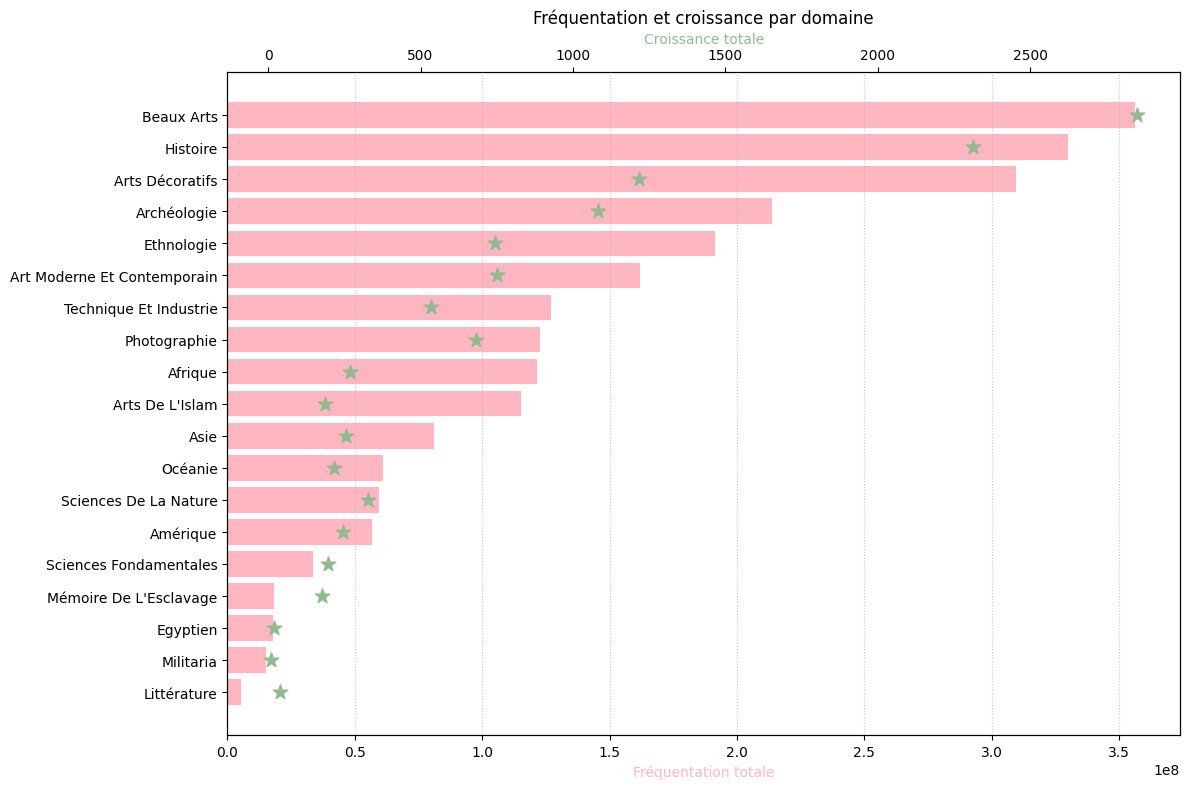

In [50]:
# FRÉQUENTATION ET CROISSANCE MOYENNE DE CHAQUE DOMAINE

domain_cols = df.filter(regex="^is_")

# Fréquentation par domaine
freq = {
    col.replace("is_", "").replace("_", " ").title():   # nettoyage pour l'affichage
        df.loc[df[col] == 1, "total"].sum()
    for col in domain_cols.columns
}

# Croissance par domaine 
croissance = {
    col.replace("is_", "").replace("_", " ").title():
        df.loc[df[col] == 1, "croissance_total"].sum()
    for col in domain_cols.columns
}

# Transformation en séries et tri
freq = pd.Series(freq).dropna()
croissance = pd.Series(croissance).dropna()

# DataFrame combiné pour aligner les domaines
df_metrics = pd.DataFrame({
    "frequentation": freq,
    "croissance": croissance
}).dropna()  # supprime les domaines manquants dans l'une ou l'autre métrique

df_metrics = df_metrics.sort_values(by='frequentation', ascending=True)

domaines = df_metrics.index

fig, ax1 = plt.subplots(figsize=(12,8))

# Définition du premier axe
ax1.barh(domaines, df_metrics['frequentation'], color='lightpink', label='Fréquentation')
ax1.set_xlabel("Fréquentation totale", color='lightpink')
ax1.grid(axis='x', linestyle=':', alpha=0.7)

# Définition du deuxième axe
ax2 = ax1.twiny()
ax2.scatter(df_metrics['croissance'], domaines, color='darkseagreen', s=120, marker='*', label='Croissance')
ax2.set_xlabel("Croissance totale", color='darkseagreen')

plt.title("Fréquentation et croissance par domaine")
plt.tight_layout()
plt.show()



On constate que les domaines thématiques les plus attractifs correspondent généralement aux musées les plus fréquentés. La relation entre fréquentation et croissance apparaît clairement : les musées bénéficiant d’une forte fréquentation sont également ceux dont la fréquentation a le plus augmenté. Cela suggère que les préférences des visiteurs sont restées relativement stables au cours des dix dernières années.

À VERIFIER, CITER CHIFFRES

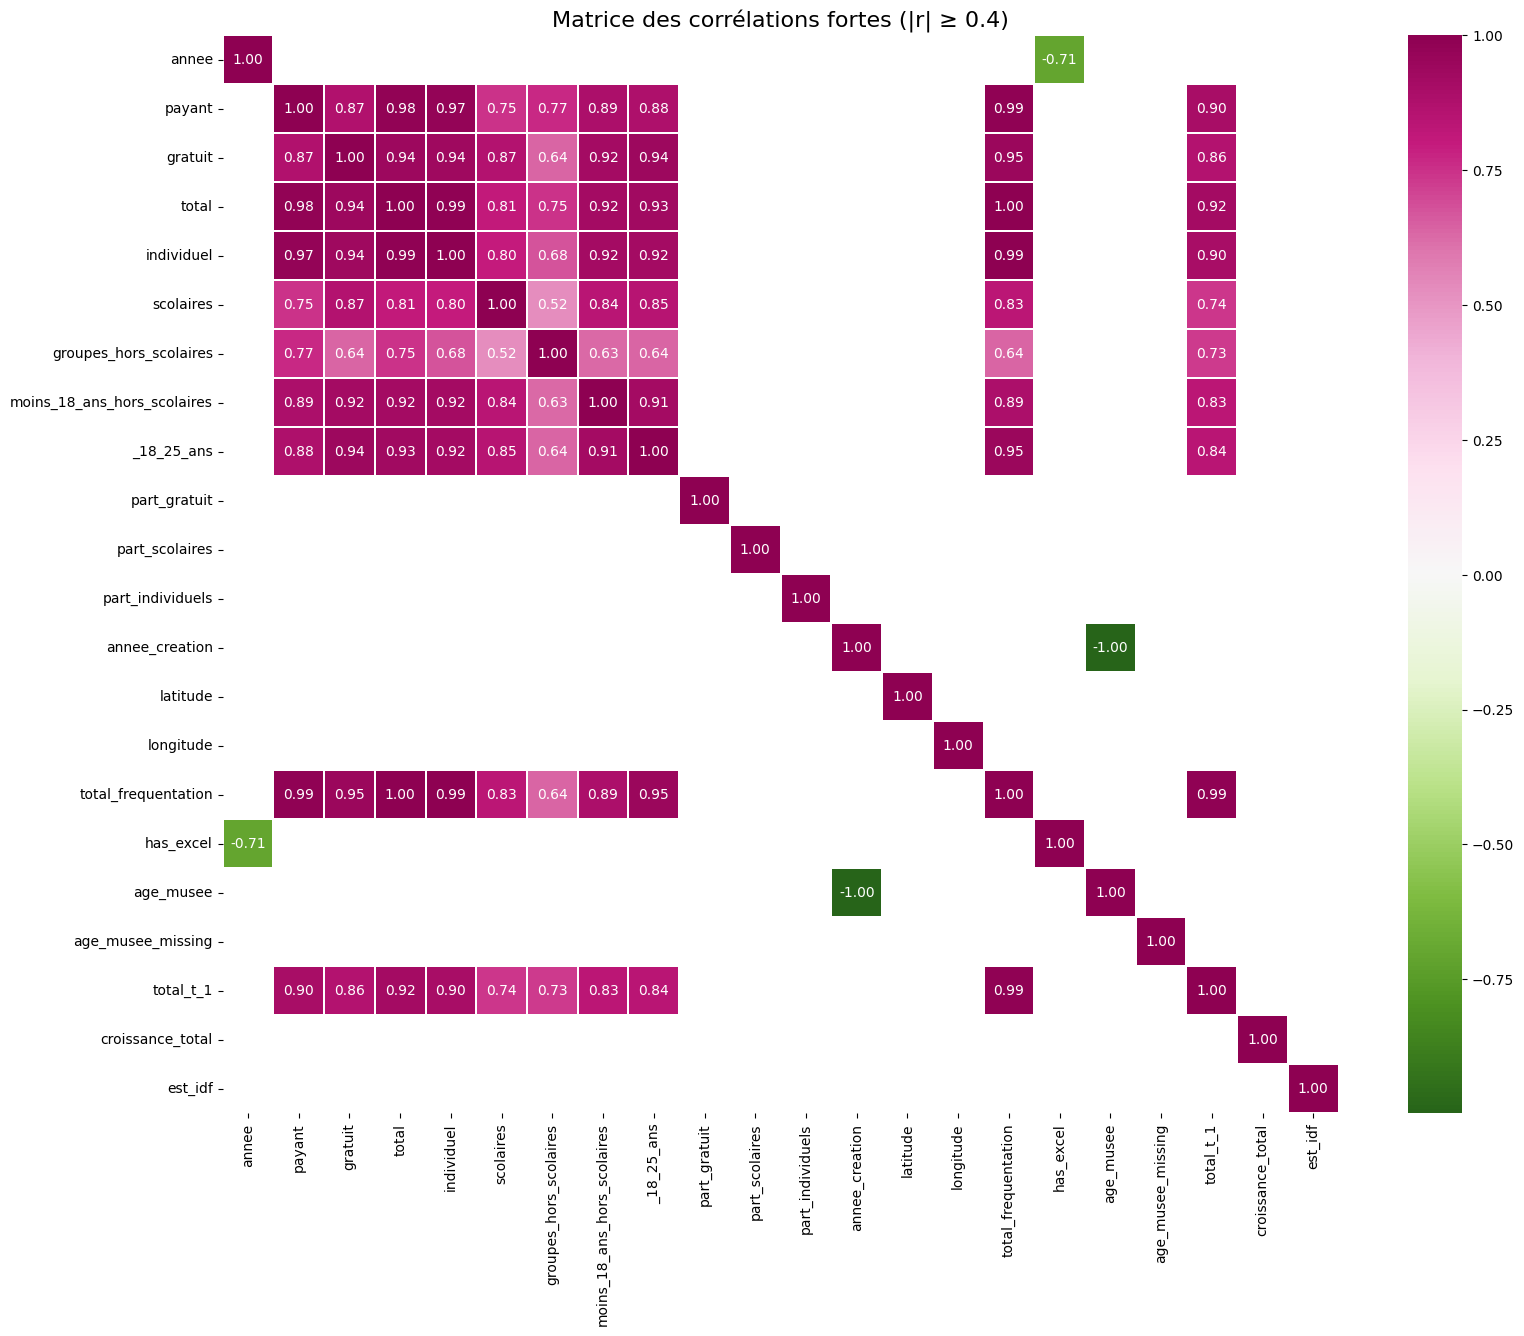

In [20]:
# MATRICE DES CORRÉLATIONS - SANS LES DOMAINES THÉMATIQUES

# Sélectionner uniquement les colonnes numériques
num_cols = df.select_dtypes(include='number')

# Supprimer les colonnes de domaine
num_cols = num_cols.loc[:, ~num_cols.columns.str.startswith("is_")]

# Sélectionner que les corrélation fortes (au moins 0.4 ou au plus -0.4)
corr = num_cols.corr()
strong_corr = corr.where(corr.abs() >= 0.4)

plt.figure(figsize=(18, 14))
sns.heatmap(
    strong_corr,
    cmap="PiYG_r",
    annot=True,       # affiche les valeurs de chaque case    
    center=0,  
    linewidths=0.3,
    fmt=".2f"         # précision au centième près dans chaque case
)

plt.title("Matrice des corrélations fortes (|r| ≥ 0.4)", fontsize=16)
plt.show()

Le bloc principal, en haut à gauche de la matrice, montre des corrélations très fortes entre les variables de fréquentation. Cela confirme un phénomène de taille : les musées les plus fréquentés attirent toutes les catégories de visiteurs. Néanmoins, cela implique une multicolinéarité élevée, qu'il faudra faire prendre en compte dans notre modèle prédictif. 

La faible corrélation avec la lattitude et la longitude semble indiquer que la localisation géographique n'explique pas le volume des visiteurs. 

La corrélation très forte entre total_t_1 et total_frequentation (r ≈ 0.92) indique que la fréquentation d’une année est fortement liée à celle de l’année précédente, ce qui nous conforte dans la possibilité et la pertinence d'un modèle prédisant l'évolution de la fréquentation.

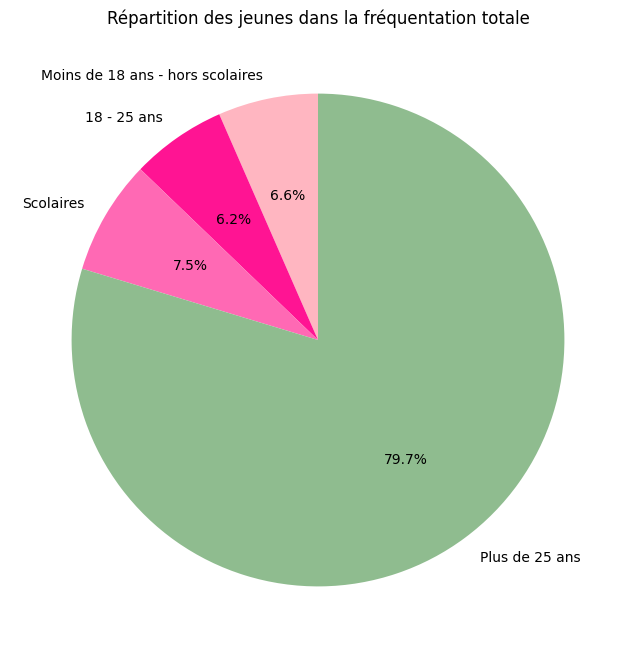